# 01 — Running HealthSynth

## How can we explore pharmaceutical commercial analytics without using confidential data?

Welcome to HealthSynth.

In this notebook, we will generate our first simulated pharmaceutical market and explore the datasets that emerge from it.

HealthSynth is different from a typical synthetic-data generator. It does not begin with a collection of unrelated tables. It begins with a commercial world containing markets, products, healthcare professionals, promotional activity, demand, competition, and prescriptions.

The datasets are produced by simulating how those parts interact over time.

By the end of this notebook, you will know how to:

- run HealthSynth from Python
- generate a complete simulated market
- understand the main datasets
- inspect the generated HCP and product populations
- query the exported data with DuckDB
- use a YAML profile to change the commercial world

No prior pharmaceutical knowledge is required.

## The Basic Idea

Every HealthSynth run follows the same general flow:

```text
Configuration
      ↓
Commercial World
      ↓
Markets, Products and HCPs
      ↓
Commercial Activity
      ↓
Market Demand and Competition
      ↓
Prescriptions
      ↓
CSV, DuckDB and Validation Outputs
```

The important point is that these outputs are connected.

For example:

- products belong to a market
- promotional calls influence commercial behaviour
- market demand determines the total available prescription volume
- market share determines how that demand is divided among products
- prescriptions are allocated across healthcare professionals

Changing the commercial configuration can therefore affect several downstream datasets at once.

## Import the Tools

We will use:

- `generate` to run HealthSynth
- `pandas` to inspect the generated datasets
- `matplotlib` for a simple visualization
- `duckdb` to query the exported database using SQL
- `Path` to inspect the files written to disk

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

## Generate the First Simulation

We will begin with a small simulation so that it runs quickly.

The main arguments are:

| Argument | Meaning |
|---|---|
| `hcps` | Number of healthcare professionals to generate |
| `years` | Length of the simulated timeline |
| `seed` | Random seed used to make the run reproducible |
| `output_dir` | Folder where exported files will be written |
| `output_format` | Export format such as CSV, DuckDB, or both |

A fixed seed means that running the same configuration again should produce the same result.

In [2]:
output_dir = Path("../output/notebook_01_first_run")

datasets = generate(
    hcps=250,
    years=2,
    seed=42,
    output_dir=str(output_dir),
    output_format="all",
)

## What Did HealthSynth Return?

The Python API returns a dictionary of pandas DataFrames.

Each key represents one part of the simulated commercial world.

In [3]:
sorted(datasets.keys())

['_stage_timings',
 '_timings',
 'call_activity',
 'hcp_master',
 'market',
 'market_demand',
 'market_share',
 'prescriptions',
 'product',
 'promotion_effect']

The exact list may evolve as HealthSynth adds new capabilities, but the core datasets usually include:

| Dataset | What it represents |
|---|---|
| `market` | Definition of the simulated market |
| `hcp_master` | Healthcare professionals in the market |
| `product` | Products competing in the market |
| `call_activity` | Promotional interactions with HCPs |
| `promotion_effect` | Monthly promotional influence by product |
| `market_demand` | Total monthly prescription opportunity |
| `market_share` | Product share of the market over time |
| `prescriptions` | Generated NRx and TRx allocated to HCPs |

These are not independent sample files. They are different views of the same simulated commercial environment.

## Check the Size of Each Dataset

Before examining individual records, it is useful to understand how much data was generated.

In [6]:
dataset_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": len(df),
            "columns": len(df.columns),
        }
        for name, df in datasets.items()
        if isinstance(df, pd.DataFrame)
    ]
).sort_values("dataset")

dataset_summary.reset_index(drop=True)

,dataset,rows,columns
0,call_activity,12400,8
1,hcp_master,250,12
2,market,1,5
3,market_demand,72,7
4,market_share,72,11
5,prescriptions,18000,7
6,product,3,10
7,promotion_effect,72,5


Different datasets have different grains.

For example:

- `market` may contain one row per market
- `product` contains one row per product
- `market_share` contains one row per product and month
- `call_activity` contains one row per promotional interaction
- `prescriptions` contains one row per HCP, product, and month

Understanding the grain of a dataset is an essential first step in analytics.

## Explore the Market

The market table describes the commercial environment being simulated.

In [7]:
market = datasets["market"]

market

,market_id,market_name,country,locale,profile_name
0,MKT_CA,Canada Commercial,Canada,None,custom


## Explore the Product Portfolio

The product master describes which brands compete in the market.

Product attributes are used later by the simulation when calculating market share, commercial events, and prescription allocation.

In [8]:
products = datasets["product"]

product_columns = [
    column
    for column in [
        "product_id",
        "product_name",
        "manufacturer",
        "brand_type",
        "therapeutic_area",
        "launch_date",
        "baseline_market_share",
    ]
    if column in products.columns
]

products[product_columns]

,product_id,product_name,manufacturer,brand_type,therapeutic_area,launch_date,baseline_market_share
0,P001,CardioOne,NVA Pharma,Innovator,Cardiology,2023-01-01,1.0
1,P002,NeuroMax,NVA Pharma,Innovator,Neurology,2022-07-01,1.0
2,P003,EndoCare,NVA Pharma,Innovator,Endocrinology,2021-01-01,1.0


The `baseline_market_share` represents the starting competitive assumption for each product.

It is not necessarily the final observed share in every month. Promotion, product availability, commercial events, and market variation can all change the adjusted result.

## Explore the Healthcare Professionals

Healthcare professionals, or HCPs, are central to pharmaceutical customer analytics.

The HCP master provides the customer population used throughout the simulation. Attributes such as specialty, decile, segment, and territory can influence targeting, promotional activity, and prescription allocation.

In [9]:
hcps = datasets["hcp_master"]

hcps.head()

,market_id,hcp_id,hcp_name,specialty,decile,segment,territory_id,territory_name,rep_id,rep_name,city,province
0,MKT_CA,HCP000001,Margaret Hawkins DDS,Neurology,8,High,T014,Territory 014,REP014,Michele Williams,East Lydiamouth,Nova Scotia
1,MKT_CA,HCP000002,Daniel Hahn,Primary Care,7,Medium,T009,Territory 009,REP009,Gabrielle Davis,Jasonfort,Nova Scotia
2,MKT_CA,HCP000003,Maria Thomas,Oncology,10,High,T015,Territory 015,REP015,Dylan Miller,East Julie,Ontario
3,MKT_CA,HCP000004,Kevin Hurst,Cardiology,2,Low,T016,Territory 016,REP016,Brian Ramirez,Coxberg,Ontario
4,MKT_CA,HCP000005,Peter Callahan Jr.,Endocrinology,5,Medium,T004,Territory 004,REP004,Daniel Wagner,Port Erin,Prince Edward Island


In [10]:
hcp_columns = [
    column
    for column in [
        "hcp_id",
        "specialty",
        "decile",
        "segment",
        "territory_id",
        "rep_id",
    ]
    if column in hcps.columns
]

hcps[hcp_columns].head(10)

,hcp_id,specialty,decile,segment,territory_id,rep_id
0,HCP000001,Neurology,8,High,T014,REP014
1,HCP000002,Primary Care,7,Medium,T009,REP009
2,HCP000003,Oncology,10,High,T015,REP015
3,HCP000004,Cardiology,2,Low,T016,REP016
4,HCP000005,Endocrinology,5,Medium,T004,REP004
5,HCP000006,Cardiology,8,High,T019,REP019
6,HCP000007,Primary Care,3,Low,T002,REP002
7,HCP000008,Endocrinology,8,High,T012,REP012
8,HCP000009,Pulmonology,7,Medium,T015,REP015
9,HCP000010,Oncology,9,High,T008,REP008


## What Specialties Exist in the Market?

Specialty is commercially important because products may be more relevant to some HCP groups than others.

Later notebooks will show how specialty affinity influences prescription allocation.

In [11]:
specialty_counts = (
    hcps["specialty"]
    .value_counts()
    .rename_axis("specialty")
    .reset_index(name="hcp_count")
)

specialty_counts

,specialty,hcp_count
0,Primary Care,90
1,Endocrinology,46
2,Cardiology,41
3,Pulmonology,26
4,Oncology,24
5,Neurology,23


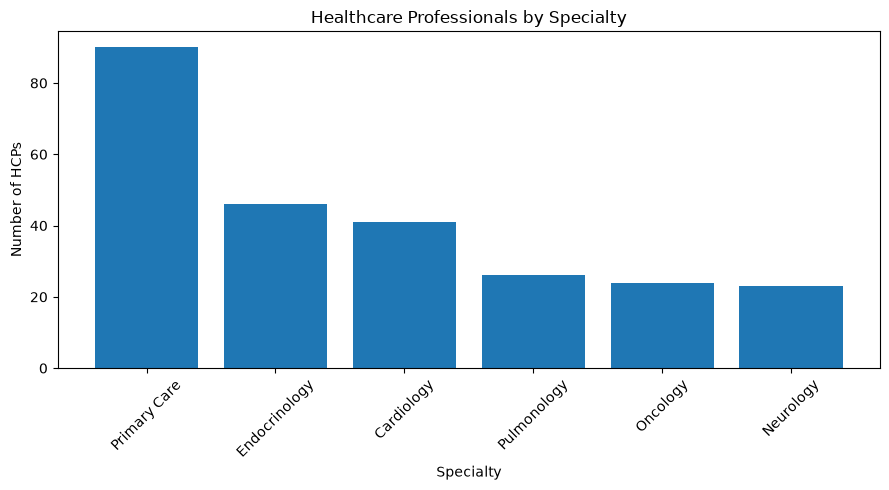

In [12]:
plt.figure(figsize=(9, 5))

plt.bar(
    specialty_counts["specialty"],
    specialty_counts["hcp_count"],
)

plt.title("Healthcare Professionals by Specialty")
plt.xlabel("Specialty")
plt.ylabel("Number of HCPs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The specialty mix defines the customer population available to the commercial organization.

A market dominated by oncology specialists will behave differently from one dominated by primary-care physicians. The distribution therefore becomes part of the commercial world rather than merely a descriptive field in a table.

## Follow the Data Through the Simulation

Let us inspect one row from several connected datasets.

In [13]:
for dataset_name in [
    "call_activity",
    "promotion_effect",
    "market_demand",
    "market_share",
    "prescriptions",
]:
    print(f"\n{dataset_name}")
    display(datasets[dataset_name].head(3))


call_activity


,market_id,call_id,call_date,hcp_id,rep_id,product_id,channel,sample_dropped
0,MKT_CA,CALL000000001,2023-01-14,HCP000001,REP014,P003,Rep Call,False
1,MKT_CA,CALL000000002,2023-01-20,HCP000001,REP014,P003,Webinar,False
2,MKT_CA,CALL000000003,2023-01-08,HCP000001,REP014,P002,Email,True



promotion_effect


,market_id,month,product_id,promotion_score,promotion_index
0,MKT_CA,2023-01,P001,134.80,0.903485
1,MKT_CA,2023-01,P002,119.65,0.801944
2,MKT_CA,2023-01,P003,142.85,0.957440



market_demand


,market_id,month,therapeutic_area,base_market_nrx,growth_factor,seasonality_factor,market_nrx
0,MKT_CA,2023-01-01,Cardiology,1200.0,1.0000,0.95,1137
1,MKT_CA,2023-02-01,Cardiology,1200.0,1.0100,0.98,1173
2,MKT_CA,2023-03-01,Cardiology,1200.0,1.0201,1.00,1268



market_share


,market_id,month,therapeutic_area,product_id,baseline_market_share,base_adoption_factor,promotion_acceleration,effective_adoption_factor,adjusted_market_share,loe_factor,market_access_factor
0,MKT_CA,2023-01-01,Cardiology,P001,1.0,1.0,0.0,1.0,1.0,1.0,1.0
1,MKT_CA,2023-02-01,Cardiology,P001,1.0,1.0,0.0,1.0,1.0,1.0,1.0
2,MKT_CA,2023-03-01,Cardiology,P001,1.0,1.0,0.0,1.0,1.0,1.0,1.0



prescriptions


,market_id,rx_id,rx_date,hcp_id,product_id,nrx,trx
0,MKT_CA,RX000000001,2023-01-01,HCP000001,P001,1,2
1,MKT_CA,RX000000002,2023-01-01,HCP000002,P001,6,10
2,MKT_CA,RX000000003,2023-01-01,HCP000003,P001,3,7


These datasets describe different stages of the same commercial process:

```text
HCP and Product Masters
        ↓
Promotional Calls
        ↓
Promotion Effect
        ↓
Market Demand and Market Share
        ↓
Prescription Allocation
```

At this stage, the goal is not to understand every calculation. Later notebooks examine each part in detail.

For now, notice that common identifiers and dates connect the datasets:

- `product_id`
- `hcp_id`
- `market_id`
- month or transaction date

## Inspect the Files Written to Disk

HealthSynth also exports the generated datasets so that they can be used outside Python.

Because we selected `output_format="all"`, the output directory should contain CSV files, a DuckDB database, a manifest, and a validation report.

In [14]:
generated_files = sorted(
    path.name
    for path in output_dir.iterdir()
)

generated_files

['call_activity.csv',
 'hcp_master.csv',
 'healthsynth.duckdb',
 'healthsynth_manifest.json',
 'market.csv',
 'market_demand.csv',
 'market_share.csv',
 'prescriptions.csv',
 'product.csv',
 'promotion_effect.csv',
 'validation_report.md']

In [15]:
file_summary = pd.DataFrame(
    [
        {
            "file": path.name,
            "size_kb": round(path.stat().st_size / 1024, 2),
        }
        for path in sorted(output_dir.iterdir())
        if path.is_file()
    ]
)

file_summary

,file,size_kb
0,call_activity.csv,837.57
1,hcp_master.csv,29.14
2,healthsynth.duckdb,2316.00
3,healthsynth_manifest.json,0.74
4,market.csv,0.09
5,market_demand.csv,4.53
6,market_share.csv,4.66
7,prescriptions.csv,887.76
8,product.csv,0.37
9,promotion_effect.csv,3.29


## Why DuckDB?

DuckDB is an embedded analytical database.

It allows us to query generated data with SQL without installing or managing a separate database server. This makes it well suited to local learning, prototyping, and dashboard preparation.

HealthSynth exports the same simulated datasets into a DuckDB database so they can be explored immediately.

In [16]:
duckdb_files = list(output_dir.glob("*.duckdb")) + list(
    output_dir.glob("*.db")
)

duckdb_files

[WindowsPath('../output/notebook_01_first_run/healthsynth.duckdb')]

In [17]:
if not duckdb_files:
    raise FileNotFoundError(
        "No DuckDB database was found in the output directory."
    )

database_path = duckdb_files[0]

connection = duckdb.connect(str(database_path))

## Discover the Available Tables

A useful first SQL query is to inspect the database catalog.    

In [18]:
connection.execute("SHOW TABLES").df()

,name
0,call_activity
1,hcp_master
2,market
3,market_demand
4,market_share
5,prescriptions
6,product
7,promotion_effect


## Query Prescriptions with SQL

The following query calculates total new prescriptions, or NRx, by product.

You do not need to understand pharmaceutical terminology yet. For this notebook, think of NRx as the volume of newly generated prescriptions associated with a product.

In [19]:
nrx_by_product = connection.execute(
    """
    SELECT
        p.product_id,
        pr.product_name,
        SUM(p.nrx) AS total_nrx
    FROM prescriptions AS p
    LEFT JOIN product AS pr
        ON p.product_id = pr.product_id
    GROUP BY
        p.product_id,
        pr.product_name
    ORDER BY
        total_nrx DESC
    """
).df()

nrx_by_product

,product_id,product_name,total_nrx
0,P001,CardioOne,32198.0
1,P003,EndoCare,24287.0
2,P002,NeuroMax,21256.0


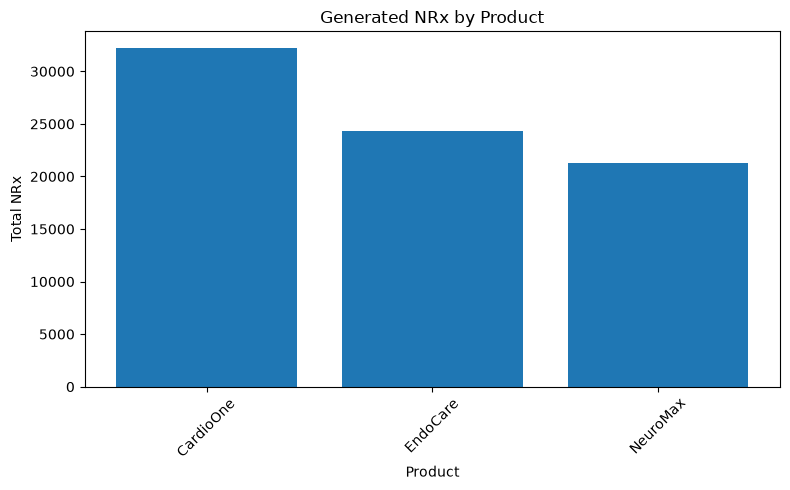

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    nrx_by_product["product_name"],
    nrx_by_product["total_nrx"],
)

plt.title("Generated NRx by Product")
plt.xlabel("Product")
plt.ylabel("Total NRx")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What This Demonstrates

The same simulated market can now be explored in several ways:

- pandas for data analysis
- SQL through DuckDB
- CSV files for BI and data-engineering tools
- notebooks for guided learning

HealthSynth is intended to produce data that can be used in realistic analytics workflows rather than only displayed as generator output.

In [21]:
connection.close()

## Use a Market Profile

So far, we used HealthSynth's default configuration and overrode a few generation parameters.

The more interesting behaviour comes from YAML profiles.

A profile defines the commercial world before the simulation starts. It can describe:

- the market and country
- the HCP specialty mix
- the product portfolio
- baseline market shares
- channel distributions
- product affinity
- market demand assumptions
- commercial events such as launches, LOE, or market-access changes

The simulation engine remains the same. The profile changes the world being simulated.

For a first profile-driven run, we will use the oncology training configuration.

This notebook is located in the top-level `notebooks` directory, so the profile is one level above it in `configs/profiles`.

In [22]:
profile_output_dir = Path(
    "../output/notebook_01_oncology_profile"
)

profile_datasets = generate(
    config_path="../configs/profiles/oncology_training.yaml",
    hcps=250,
    output_dir=str(profile_output_dir),
)

## Compare the Default and Profile-Driven Markets

The purpose of this comparison is not to analyse the oncology profile in depth. Notebook 02 will do that.

Here, we only want to see that changing the configuration changes the generated commercial world.

In [23]:
comparison = pd.DataFrame(
    [
        {
            "simulation": "Default",
            "markets": len(datasets["market"]),
            "products": len(datasets["product"]),
            "hcps": len(datasets["hcp_master"]),
            "calls": len(datasets["call_activity"]),
            "prescription_rows": len(datasets["prescriptions"]),
        },
        {
            "simulation": "Oncology profile",
            "markets": len(profile_datasets["market"]),
            "products": len(profile_datasets["product"]),
            "hcps": len(profile_datasets["hcp_master"]),
            "calls": len(profile_datasets["call_activity"]),
            "prescription_rows": len(
                profile_datasets["prescriptions"]
            ),
        },
    ]
)

comparison

,simulation,markets,products,hcps,calls,prescription_rows
0,Default,1,3,250,12400,18000
1,Oncology profile,1,3,250,18627,27000


In [24]:
profile_datasets["product"][
    [
        column
        for column in [
            "product_id",
            "product_name",
            "therapeutic_area",
            "manufacturer",
            "brand_type",
            "baseline_market_share",
        ]
        if column in profile_datasets["product"].columns
    ]
]

,product_id,product_name,therapeutic_area,manufacturer,brand_type,baseline_market_share
0,P001,OncoNova,Oncology,NVA Pharma,Innovator,0.45
1,P002,Tumora,Oncology,Competitor A,Competitor,0.35
2,P003,Immunex,Oncology,Competitor B,Competitor,0.20


### Profiles Separate Configuration from Code

This separation is important.

A learner can change the simulated market without rewriting the generation engine.

```text
Same HealthSynth Engine
        +
Different YAML Profile
        =
Different Commercial World
```

Notebook 02 explores profiles in more detail.

## Reproducibility

HealthSynth uses a random seed.

Running the same simulation with the same profile, parameters, and seed should produce the same result. This makes experiments easier to compare.

Changing the seed produces a different—but still commercially consistent—synthetic population.

In [25]:
repeat_run = generate(
    hcps=50,
    years=1,
    seed=42,
    output_dir="../output/notebook_01_seed_42_repeat",
    output_format="csv",
)

alternate_seed_run = generate(
    hcps=50,
    years=1,
    seed=99,
    output_dir="../output/notebook_01_seed_99",
    output_format="csv",
)

In [26]:
same_seed_example = datasets["hcp_master"].head(3)

alternate_seed_example = alternate_seed_run[
    "hcp_master"
].head(3)

display(same_seed_example)
display(alternate_seed_example)

,market_id,hcp_id,hcp_name,specialty,decile,segment,territory_id,territory_name,rep_id,rep_name,city,province
0,MKT_CA,HCP000001,Margaret Hawkins DDS,Neurology,8,High,T014,Territory 014,REP014,Michele Williams,East Lydiamouth,Nova Scotia
1,MKT_CA,HCP000002,Daniel Hahn,Primary Care,7,Medium,T009,Territory 009,REP009,Gabrielle Davis,Jasonfort,Nova Scotia
2,MKT_CA,HCP000003,Maria Thomas,Oncology,10,High,T015,Territory 015,REP015,Dylan Miller,East Julie,Ontario


,market_id,hcp_id,hcp_name,specialty,decile,segment,territory_id,territory_name,rep_id,rep_name,city,province
0,MKT_CA,HCP000001,Phillip Gomez,Cardiology,6,Medium,T016,Territory 016,REP016,John Weiss,Nielsenberg,Saskatchewan
1,MKT_CA,HCP000002,Linda Burgess,Endocrinology,10,High,T012,Territory 012,REP012,Vanessa Howard,Martinezville,Manitoba
2,MKT_CA,HCP000003,William Ortiz,Endocrinology,6,Medium,T013,Territory 013,REP013,Thomas Martin,New Luis,Nunavut


The exact HCP records change when the seed changes.

The structure and business rules remain the same.

This allows us to create multiple synthetic populations while preserving the assumptions defined by the configuration.

## Key Takeaways

You have now generated and explored your first HealthSynth simulations.

The main ideas from this notebook are:

- HealthSynth simulates a commercial world rather than isolated tables.
- The generated datasets describe connected stages of that world.
- The Python API returns pandas DataFrames for immediate analysis.
- HealthSynth can export CSV and DuckDB outputs.
- DuckDB makes the generated data directly queryable with SQL.
- YAML profiles change the simulated market without changing Python code.
- Random seeds make runs reproducible.

The goal is not merely to create synthetic records. It is to create a safe environment in which commercial analytics can be explored and learned.

## Try It Yourself

Before moving to the next notebook, try changing one parameter at a time.

### Experiment 1 — Market size

Change:

```python
hcps=250
```

to:

```python
hcps=1000
```

Which datasets gain more rows?

Which datasets remain the same size?

---

### Experiment 2 — Simulation length

Change:

```python
years=2
```

to:

```python
years=5
```

Which datasets grow with the number of months?

---

### Experiment 3 — Random seed

Run the same configuration with two different seeds.

Which values change?

Which business rules remain consistent?

---

### Experiment 4 — Output format

Try:

```python
output_format="csv"
```

and then:

```python
output_format="duckdb"
```

How does the output directory change?

Before running each experiment, predict what you expect to happen.

## What's Next?

In Notebook 02, we will explore **Market Profiles**.

We will look inside the YAML configuration and learn how HealthSynth defines:

- a market
- its healthcare-professional population
- its products
- its channels
- product affinity
- demand assumptions

Notebook 01 showed how to run the engine.

Notebook 02 begins explaining how the commercial world is designed.